In [1]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss
from sklearn.metrics import ConfusionMatrixDisplay 
from sklearn.calibration import CalibratedClassifierCV

In [2]:
matches = pd.read_csv('../data/processed/features_v6.csv')

In [3]:
features = [
    "EloDiff",
    "XGDDiffLast5",
    "GoalsPerGameDiff"
]

In [4]:
train = matches[matches['Season'] != '25-26'] 
test = matches[matches['Season'] == '25-26']

In [5]:
X_train = train[features] 
y_train = train['FTR'] 
X_test = test[features] 
y_test = test['FTR']

In [6]:
 
model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

calibrated_model = CalibratedClassifierCV(
        estimator=model,
        method="sigmoid",
        cv=5
    )

calibrated_model.fit(X_train, y_train)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",LogisticRegre...ndom_state=42)
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary <n_jobs>` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
Name,Type,Value
"calibrated_classifiers_ calibrated_classifiers_: list (len() equal to cv or 1 if `ensemble=False`)The list of classifier and calibrator pairs.- When `ensemble=True`, `n_cv` fitted `estimator` and calibrator pairs. `n_cv` is the number of cross-validation folds.- When `ensemble=False`, the `estimator`, fitted on all the data, and fitted calibrator... versionchanged:: 0.24 Single calibrated classifier case when `ensemble=False`.",list,"[<sklearn.cali...00158E255E3C0>, <sk

In [7]:
preds = calibrated_model.predict(X_test)

In [8]:
accuracy = accuracy_score(y_test, preds) 
print(accuracy)

0.5026315789473684


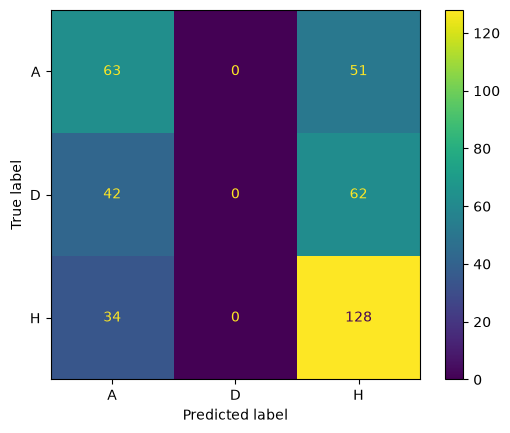

In [9]:
ConfusionMatrixDisplay.from_predictions(y_test, preds)

In [10]:
probs = calibrated_model.predict_proba(X_test) 
print(calibrated_model.classes_) 
print(probs[0])

['A' 'D' 'H']
[0.11877141 0.22191151 0.65931708]


In [16]:
coefs = np.array([
    clf.estimator.coef_
    for clf in calibrated_model.calibrated_classifiers_
])

# Average across the 5 folds
mean_coefs = coefs.mean(axis=0)


# For multiclass H/D/A, calculate one overall importance
importance = np.mean(
    np.abs(mean_coefs),
    axis=0
)

importance = pd.Series(
    importance,
    index=features
).sort_values(ascending=False)

print(importance)

XGDDiffLast5        0.143564
GoalsPerGameDiff    0.076556
EloDiff             0.002265
dtype: float64


In [12]:
print(log_loss(y_test, probs))

1.030192211128026


In [13]:
results = test[
    ["Season", "HomeTeam", "AwayTeam", "FTR"]
].copy()

results["Predicted"] = preds
results["AwayProb"] = probs[:, 0]
results["DrawProb"] = probs[:, 1]
results["HomeProb"] = probs[:, 2]

results.head(20)

,Season,HomeTeam,AwayTeam,FTR,Predicted,AwayProb,DrawProb,HomeProb
1520,25-26,Liverpool,Bournemouth,H,H,0.118771,0.221912,0.659317
1521,25-26,Aston Villa,Newcastle United,D,H,0.353618,0.283539,0.362843
1522,25-26,Brighton and Hove Albion,Fulham,D,H,0.238639,0.232565,0.528796
1523,25-26,Sunderland,West Ham United,H,H,0.270275,0.230641,0.499084
1524,25-26,Tottenham Hotspur,Burnley,H,H,0.224240,0.248551,0.527209
1525,25-26,Wolverhampton Wanderers,Manchester City,A,A,0.608791,0.218770,0.172439
1526,25-26,Chelsea,Crystal Palace,D,H,0.263984,0.261433,0.474583
1527,25-26,Nottingham Forest,Brentford,H,H,0.356346,0.273894,0.369760
1528,25-26,Manchester United,Arsenal,A,A,0.553186,0.212149,0.234665
1529,25-26,Leeds United,Everton,H,A,0.547733,0.261468,0.190800
